<a href="https://colab.research.google.com/github/javendaXgh/ucveconomiaestadistica1/blob/main/notebooks/Copia_de_Tarea_01_Aris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Indique su nombre y cédula
## Nombre: Aris Alzuro
## Cédula: 27.111.755


## Estadística I, Tarea 01
A continuación hay una serie de ejercicios que debe completar. Algunos de los códigos ya están vaciados para que se facilite realizar estar tarea.

Se recomienda para cada uno de los conjuntos de datos a trabajar, revise los datos que contienen, así como también usar las funciones de ayuda `?` obtener información sobre los mismos y de esta manera lograr facilitar la comprensión sobre los datos a trabajar.

#### Recomendaciones
Usar funciones apropiadas para obtener los valores solicitados. Revise los ejercicios de codificación anteriormente presentados en el curso, las láminas, así como el libro Open Intro Stats. <br>

Si realiza algún cálculo manualmente deberá añadir las celdas de código con tales cálculo, tantas como sea necesario.

En cada una de las celdas de código, añada comentarios con el símbolo numeral (#) al inicio de la celda para indicar los procedimientos realizados.

Recuerde cuidar la redacción y ortografía en la información que presente.

En caso de tener alguna duda sobre los procedimientos a seguir, usar el grupo de whatsapp.

Se recuerda que la terea debe ser realizada de forma individual.

In [2]:
# instalar y cargar paquetes con los que se trabajará. No modificar esta celda
install.packages ('openintro')
install.packages ('gtsummary')
library ('openintro')
library ('gtsummary')
library ('dplyr')


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘gt’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## 1) Tratamiento de tumores con etanol


### Nombre del conjunto de datos
ethanol

### Descripción
Experimento en el que se probaron 3 tratamientos diferentes de etanol para el tratamiento de tumores de cáncer oral en hámsters.

La columna "regress" especifica si el tratamiento tuvo efecto con la categoría "yes" o "no" en caso de no tener algún efecto sobre el tumor.


La columna "treatment" indica el tratamiento que recibió el hámster.


### Detalles
Los tratamientos de etil_celulosa y etanol_puro consistían en aproximadamente una cuarta parte del volumen de los tumores, mientras que el tratamiento de etanol_puro_16x era 16 veces mayor, es decir, unas 4 veces el tamaño de los tumores.

### Fuente
Morhard R, et al. 2017. Desarrollo de la ablación mejorada con etanol como alternativa a la cirugía en el tratamiento de tumores sólidos superficiales.

### Asignación
1) ¿Cómo se presentan los datos? <br>
2) ¿Cuántas observaciones tiene el conjunto de datos? <br>
3) ¿Cuántas variables tiene el conjunto de datos y cómo se llaman? <br>
4) Crear una tabla de contigencia que represente los totales por tratamiento. Calcular la frecuencia relativa de cada uno de estos experimentos y su éxito (puede usar los códigos revisados o hacerlo manualmente). <br>
5) Realice una explicación escrita sobre los resultados obtenidos (tipo de estudio, siginficado de los resultados, generalizable, etc.). Puede llegar a alguna conclusión con los datos presentados? Sea lo más explícito posible.






respuesta #1
El conjunto de datos del etanol estan presentado en forma de tabla, donde contienen informacion sobre un experimento en el que se probaron tres tratamiento diferentes de etanol para la regresion de tumores de hamsters, donde cada fila corresponde a una observacion y cada columna una variable.

respuesta #2
Este conjuto de datos tiene un total de 24 observaciones, distribuidas entre tratamientos. cada observacion corresponde a un hamster con los diferentes tratamiento, y el resultado "yes" una regresion exitosa o "no" sin exito.

In [3]:
#numero de observaciones
nrow(ethanol)
dim(ethanol)
print(ethanol)


[1] 24

[1] 24  2

# A tibble: 24 × 2
   treatment        regress
   <fct>            <fct>  
 1 pure_ethanol_16x yes    
 2 pure_ethanol_16x yes    
 3 pure_ethanol_16x yes    
 4 pure_ethanol_16x yes    
 5 pure_ethanol_16x no     
 6 pure_ethanol_16x no     
 7 pure_ethanol_16x no     
 8 pure_ethanol_16x no     
 9 pure_ethanol_16x no     
10 pure_ethanol_16x no     
# ℹ 14 more rows


respuesta #3
Este conjunto de datos contiene 2 variables
treatment: el tratamiento recibido por el hamster (variable categorica)nominal
regrees: el resultado del tratamiento indicando el exito o fracaso. (variable categorica)

In [4]:
#ver nombre de variable
names(ethanol)
#numero de variable
ncol (ethanol)
#verificar tipo de variable
str (ethanol)


[1] "treatment" "regress"

[1] 2

tibble [24 × 2] (S3: tbl_df/tbl/data.frame)
 $ treatment: Factor w/ 3 levels "ethyl_cellulose",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ regress  : Factor w/ 2 levels "no","yes": 2 2 2 2 1 1 1 1 1 1 ...


In [5]:
#crear tabla de contigencia
tabla_contigencia <-
table(ethanol$treatment,ethanol$regress)
#ver la tabla
tabla_contigencia

                  
                   no yes
  ethyl_cellulose   1   6
  pure_ethanol      5   0
  pure_ethanol_16x  8   4

In [7]:
#calcular frecuencia relativa de exito y fracaso
frecuencia_relativa <-
table(ethanol$regress) / nrow (ethanol)
#mostrar la frecuencia relativa
print (frecuencia_relativa)


       no       yes 
0.5833333 0.4166667 


observación: ver siguiente celda de código

In [13]:
# el requerimiento indicaba "Calcular la frecuencia relativa de cada uno de estos experimentos y su éxito.."
# en un primer intento se pudiera tratar de generar de esta forma
(tabla_contigencia/ nrow (ethanol))*100


# pero no estaría logrado como es necesario lo que implica buscar o hacerlo manualmente o usar la función tbl_summary
# del paquete gtsummary

# camino a seguir o calcular porcentajes manualmente
gtsummary::tbl_summary(ethanol,
                       include = 'treatment',
                       by='regress',
                       percent='row')%>%
                          as_kable()

                  
                          no       yes
  ethyl_cellulose   4.166667 25.000000
  pure_ethanol     20.833333  0.000000
  pure_ethanol_16x 33.333333 16.666667



|**Characteristic** | **no**  N = 14 | **yes**  N = 10 |
|:------------------|:--------------:|:---------------:|
|treatment          |                |                 |
|ethyl_cellulose    |    1 (14%)     |     6 (86%)     |
|pure_ethanol       |    5 (100%)    |     0 (0%)      |
|pure_ethanol_16x   |    8 (67%)     |     4 (33%)     |

In [ ]:
#calcular frecuencia de exito
frecuencia_exitos <-
  sum (ethanol$regress == "yes") / nrow (ethanol)
  #mostrar resultado
  print (frecuencia_exitos)


[1] 0.4166667


respuesta#5  
trabajamos con una serie de datos, sobre un estudio experimental que se llevo a cabo en modelo animal (hamsterm). estos fueron sometidos a tres tipos de tratamiento de ethanol, y fue registrado si el tratamiento resulto en la regresion de los tumores.
a mi parecer ya que este experimento se realizo en hamster, un modelo animal, no se se podria concluir, que aunque algunos resultados fueron prometedores, no se puede generalizar directamente a humanos, se requiere de muchos mas estudios clinicos.


In [ ]:
ethanol

treatment,regress
<fct>,<fct>
pure_ethanol_16x,yes
pure_ethanol_16x,yes
pure_ethanol_16x,yes
pure_ethanol_16x,yes
pure_ethanol_16x,no
pure_ethanol_16x,no
pure_ethanol_16x,no
pure_ethanol_16x,no
pure_ethanol_16x,no


## 2) Indicadores Económicos y de Sostenibilidad para Sudáfrica.
#### Nombre del Conjunto de Datos
sa_gdp_elec


### Descripción
Incluye datos anuales sobre pib, gni, emisiones de co2, costes de puesta en marcha.

### Detalles
año: Año de recogida de los datos.

access_elec: Acceso a la electricidad en porcentaje de la población.

puesta en marcha: Coste de los procedimientos de creación de empresas en porcentaje de la GNI.

co2: Emisión de CO2 en kt (kilotoneladas).

gdp: PIB per cápita, PPA en dólares internacionales constantes de 2017.

gni: GNI per cápita, PPA en dólares internacionales constantes de 2017. GNI (gross national income) es la cantidad total de dinero que ganan los ciudadanos y las empresas de un país.


co2_kg_ppp: kg por PIB en dólares PPA de 2017.




### Fuente

World Bank I

Carbon Dioxide Information Analysis Center, Environmental Sciences Division

### Asignación
1) ¿Cuántas observaciones tiene el conjunto de datos?

2) Indique el tipo de cada una de ls variables.

3) Realice un histograma para la variable `co2` e indique cuántas barras recomienda aplicar para visualizar este gráfico.

4) Explique si tiene sentido crear un histograma para la variable year

5) Muestre dos gráficos de dispersión entre variables que pueden estar asociadas, el tipo de relación que presenten e intente identificar cuáles pueden ser las variables explicativas y de respuesta

6) ¿Puede indentificar algunas variables que resulten independientes?. Justifique

6) Identifique el tipo de estudio que se revisó en esta sección

In [ ]:
sa_gdp_elec

year,access_elec,startup,co2,gdp,gni,co2_kg_ppp
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2003,78.8,9.4,353110,10646.83,10388.18,0.7098952
2004,80.9,9.1,379970,10997.01,10807.17,0.7306183
2005,80.8,8.6,377640,11434.92,11233.35,0.6897401
2006,80.7,6.9,379560,11924.07,11711.35,0.6564602
2007,82.0,7.1,396900,12402.05,12010.29,0.6515254
2008,81.9,6.0,426560,12628.20,12251.73,0.6785602
2009,82.6,5.9,404020,12262.14,11999.96,0.6527439
2010,82.9,6.0,425110,12452.34,12195.42,0.6665559
2011,83.6,0.3,409120,12666.71,12346.55,0.6210867


In [14]:
#verificar el numero de observaciones
nrow (sa_gdp_elec)

[1] 16

In [15]:
#ver numero de variable
ncol(sa_gdp_elec)
#verificar el tipo de variable
str(sa_gdp_elec)

[1] 7

tibble [16 × 7] (S3: tbl_df/tbl/data.frame)
 $ year       : num [1:16] 2003 2004 2005 2006 2007 ...
 $ access_elec: num [1:16] 78.8 80.9 80.8 80.7 82 81.9 82.6 82.9 83.6 85.3 ...
 $ startup    : num [1:16] 9.4 9.1 8.6 6.9 7.1 6 5.9 6 0.3 0.3 ...
 $ co2        : num [1:16] 353110 379970 377640 379560 396900 ...
 $ gdp        : num [1:16] 10647 10997 11435 11924 12402 ...
 $ gni        : num [1:16] 10388 10807 11233 11711 12010 ...
 $ co2_kg_ppp : num [1:16] 0.71 0.731 0.69 0.656 0.652 ...


todas son variables de tipo numerica, con valores continuo.

observación: La variable `year` no es continua

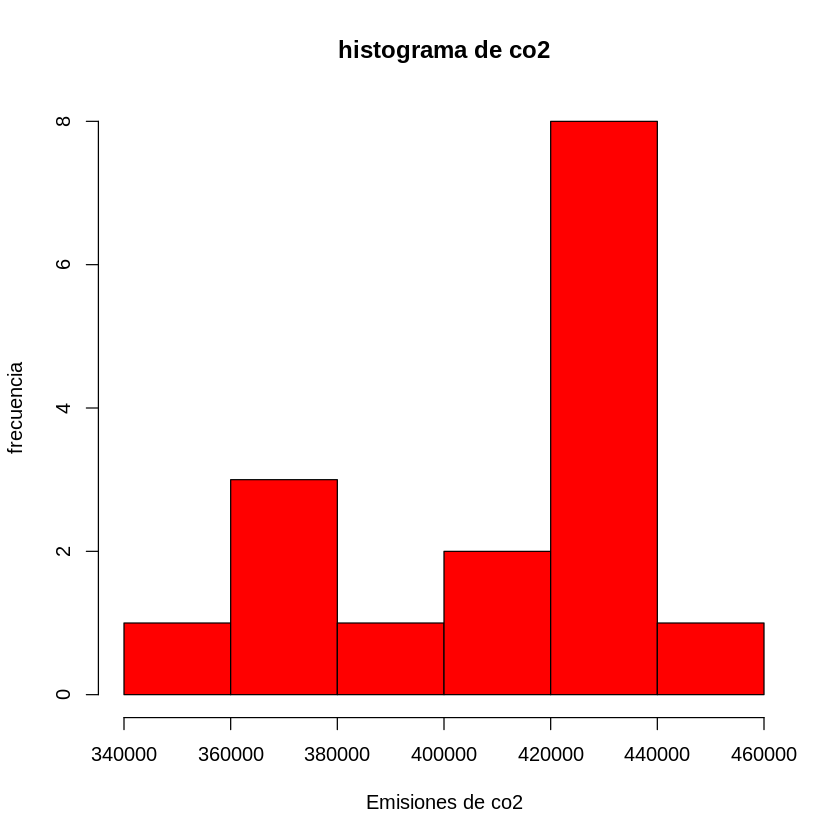

In [16]:
#crear un histograma
hist (sa_gdp_elec$co2,
main = "histograma de co2",
xlab = "Emisiones de co2",
ylab = "frecuencia",
col= "red",
border = "black",
breaks = 6)

respuesta#4
la variable year (año) es un tipo de variable categorica ordinal, crear un histograma para esta variable no seria lo mas recomendable, ya que los histogramas estan diseñados pra mostrar distribucion de variable continua. y no nos dara un analisis claro, ya que la distribucion tendria muchas barras, lo que no siempre es util.

observación: en el histograma, más que una variable continua, es para una variable numérica y no categórica. Recomiendo que generes el histograma y evalúes porque no tiene sentido en este caso, al ser solo una observación por año

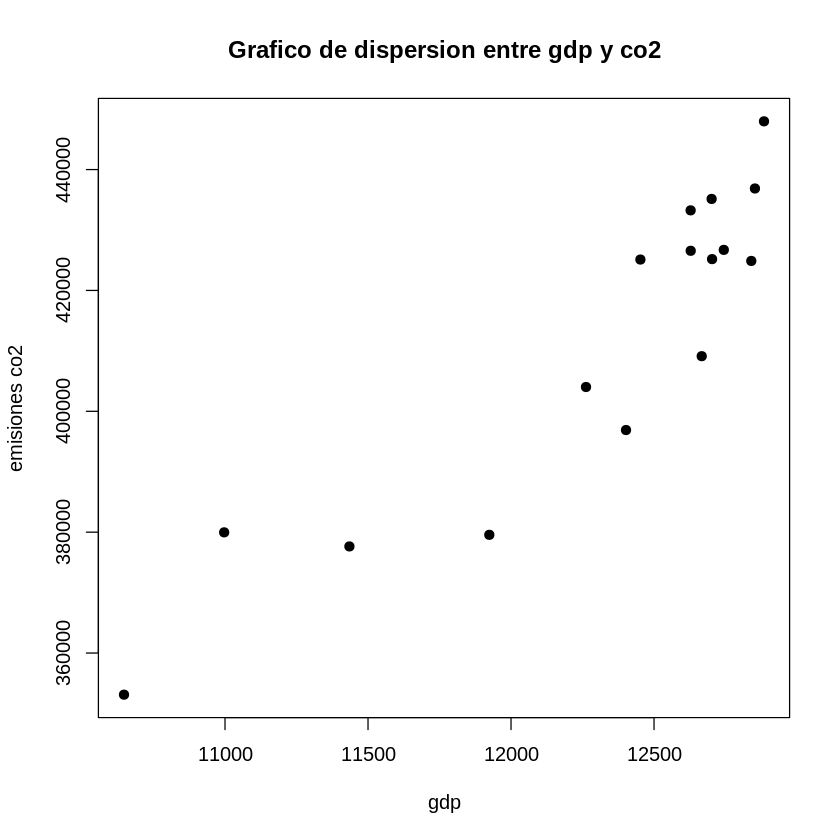

In [17]:
#grafico de dispersion gdp vs co2

plot(sa_gdp_elec$gdp, sa_gdp_elec$co2,
main = "Grafico de dispersion entre gdp y co2",
xlab= "gdp",
ylab = "emisiones co2" ,
pch = 19)

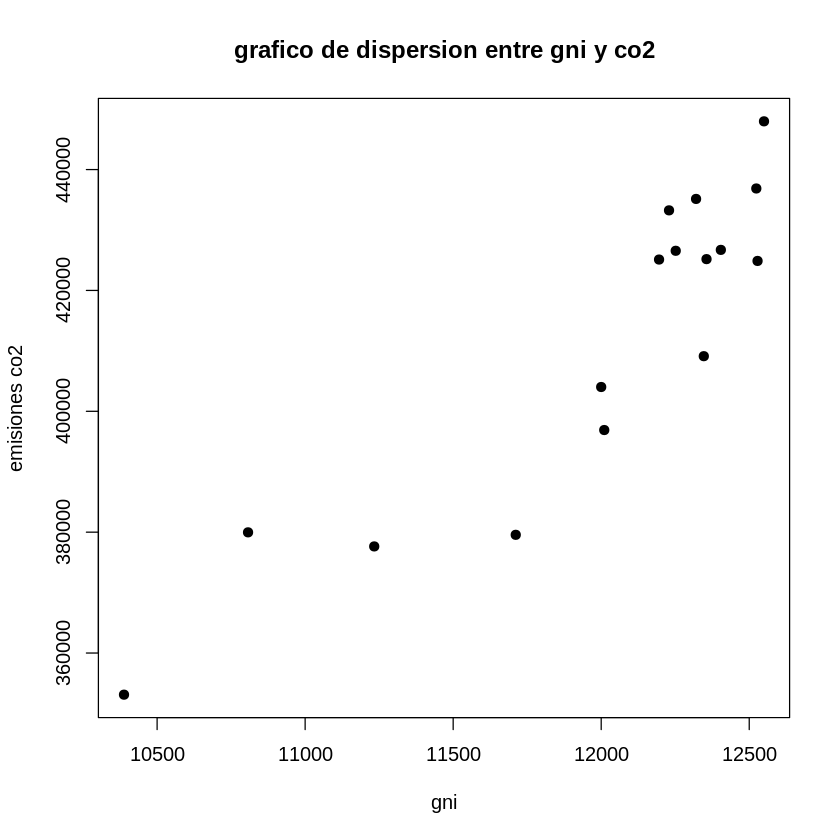

In [18]:
#segundo grafico de dispersion gni vs co2
plot (sa_gdp_elec$gni, sa_gdp_elec$co2,
main= "grafico de dispersion entre gni y co2",
xlab = "gni",
ylab= "emisiones co2",
pch = 19)

Tipos de relacion:
para el grafico gdp y co2, tenemos una relacion positiva, ya que a medida que el PIB aumenta, las emisiones de co2 tambien podrian aumentar.
2- para el grafico entre gni y co2 tambien tenemos una probable relacion positiva.

Variables explicativa y de respuesta:
 la explicativa: son gdp y gni ya que explican o influyen en el valor co2.

 la de repuesta: co2 ya que es una variable dependiente que vamos a explicar.


respuesta #6
En este conjunto de datos, la variables que podria considerarse independiente es el año.
justificando:
Año year: El año es independiente de las demas variables. es una medida de tiempo que avanza cronologicamente, y no depende de nigun otro factor en el cojuto de datos. es decir no cambia en funcion de otras variables.

## 3) Representación de Histogramas
A continuación se presenta el código para generar 3 histogramas donde cada uno corresponde a un conjunto de datos distinto. Para cada uno, realizar las siguientes actividades:

1) Generar el gráfico y determinar si variando la cantidad de barras mediante el parametro `breaks` puede mejorar la representación.

2) Identificar el conjunto de dato usado para generar los gráficos así como el nombre de la variable, especificando lo que representa y el tipo de variable.

3) Identifique la modalidad de la distribución, así como posibles sesgos, según su selección de cantidad de barras

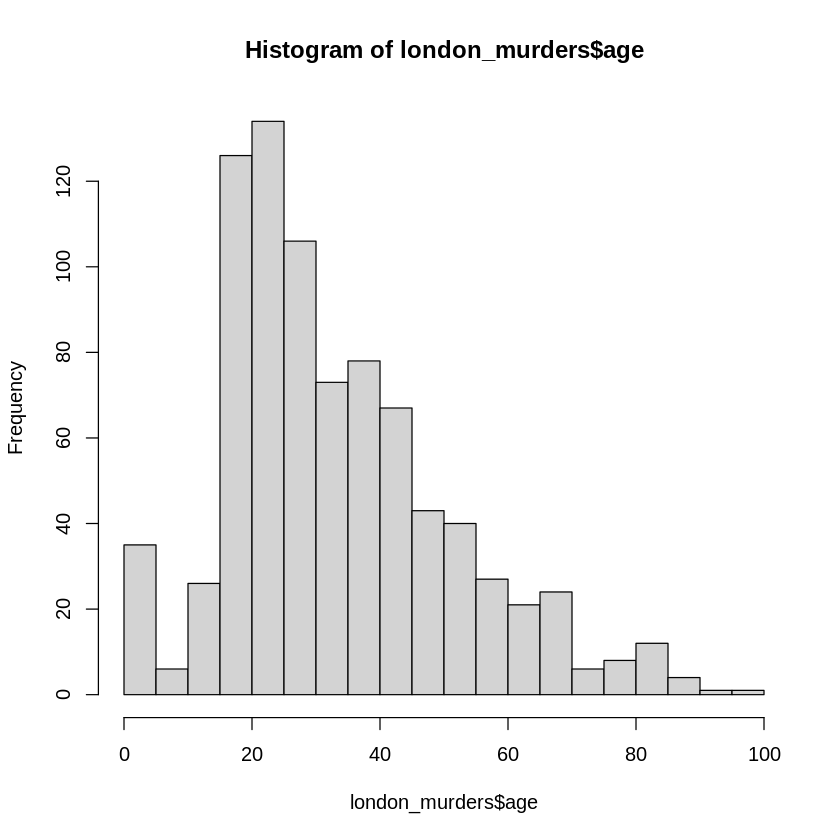

In [20]:
hist(london_murders$age, breaks = 15)

#### respuestas:
usar tantas celdas de código y texto como sea necesario

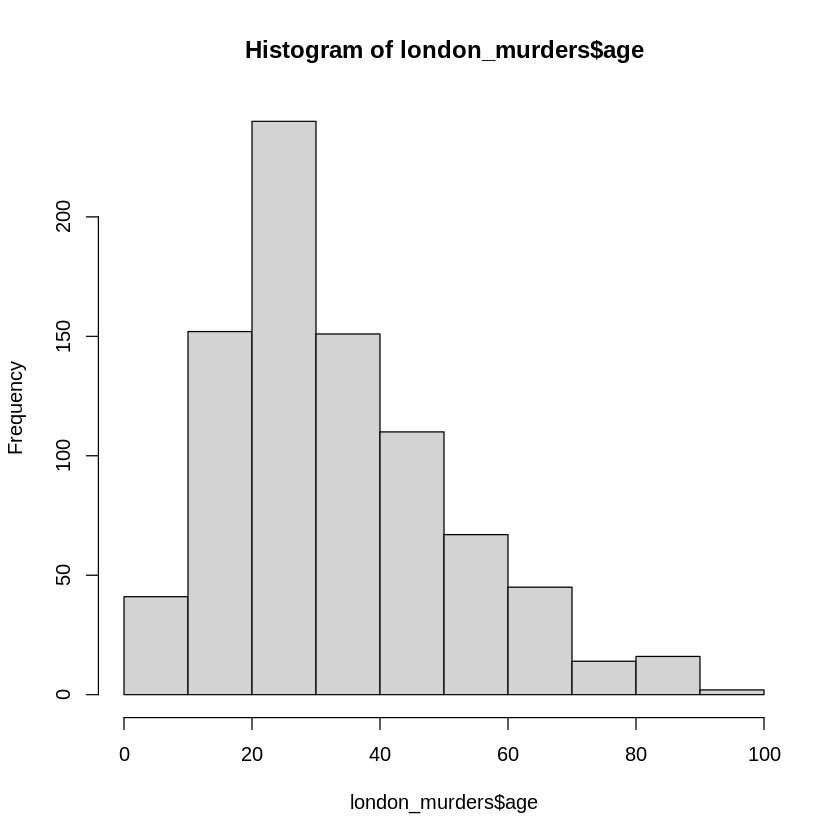

In [25]:
hist (london_murders$age, breaks = 10)

In [23]:
#crear una tabla de datos
table(london_murders$age)
#ver numeros de variable
ncol (london_murders)
#ver numero de observaciones
nrow (london_murders)
# ver nombre de variable
names(london_murders)


  1   2   3   4   5   6   8  10  12  13  14  15  16  17  18  19  20  21  22  23 
 23   3   4   2   3   1   1   4   3   1   6  16  22  24  31  20  29  27  26  30 
 24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43 
 27  24  21  24  20  25  16   8  13  21  16  15  23  10  14  18  13  12  10  16 
 44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63 
 16  13  11   8   6  10   8  10   4   9  12   5   4   5   4   3  11   4   7   3 
 64  65  66  67  68  69  70  71  72  73  76  77  78  79  80  81  82  83  84  86 
  4   3   3   8   3   4   6   2   2   2   1   1   2   2   2   3   1   4   4   2 
 88  90  91 100 
  1   1   1   1 

[1] 5

[1] 838

[1] "forename" "age"      "date"     "year"     "borough"

In [ ]:
observacion: no pude correr el código de la celda de abajo

In [24]:
#datos
(london_murders) <-

  print(tabla_histograma)

ERROR: Error: object 'tabla_histograma' not found


tipos de variables

tiene 5 variable

con la modificacion a 10 barras podemos observar un sesgo a la derecha

sin la modificación también del breaks también se aprecia el mismo sesgo. Igual, creo que mejora la representación del histograma al bajar la cantidad al número que decidiste usar. En cuanto al conjunto de datos es `?london_murders` "This dataset contains the victim name, age, and location of every murder recorded in the Greater London area by the Metropolitan Police from January 1, 2006 to September 7, 2011.". Luego desde ahí podías hacer una interpretación de la variable representada donde, por ejemplo, la moda en asesinatos es cercana a los 22 años, y así...

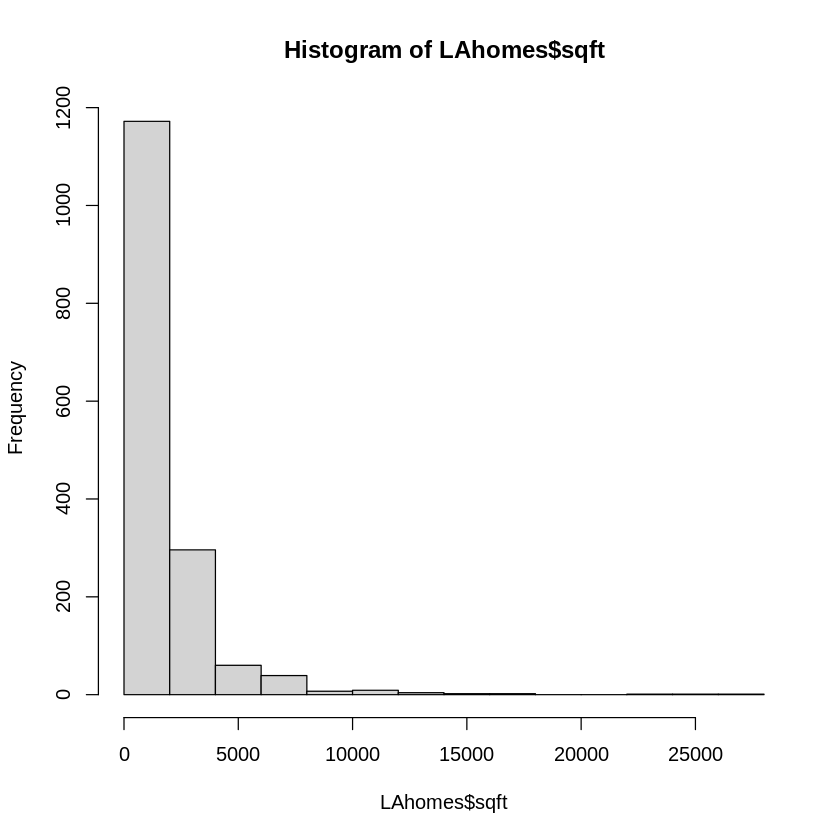

In [26]:
hist(LAhomes$sqft)

#### respuestas:
no me fue posible modifica las barras, y en este histograma podemos observar con mas magnitud un sesgo ala derecha, es un grafico que no nos muestras mucho para un analisis.


tambien observamos 2 variables


observación: no sé qué pasó que me comentas que no lo pudiste modificar. En caso de, me hubieses escrito y con gusto te ayudaba. Recuerden siempre pedir asistencia

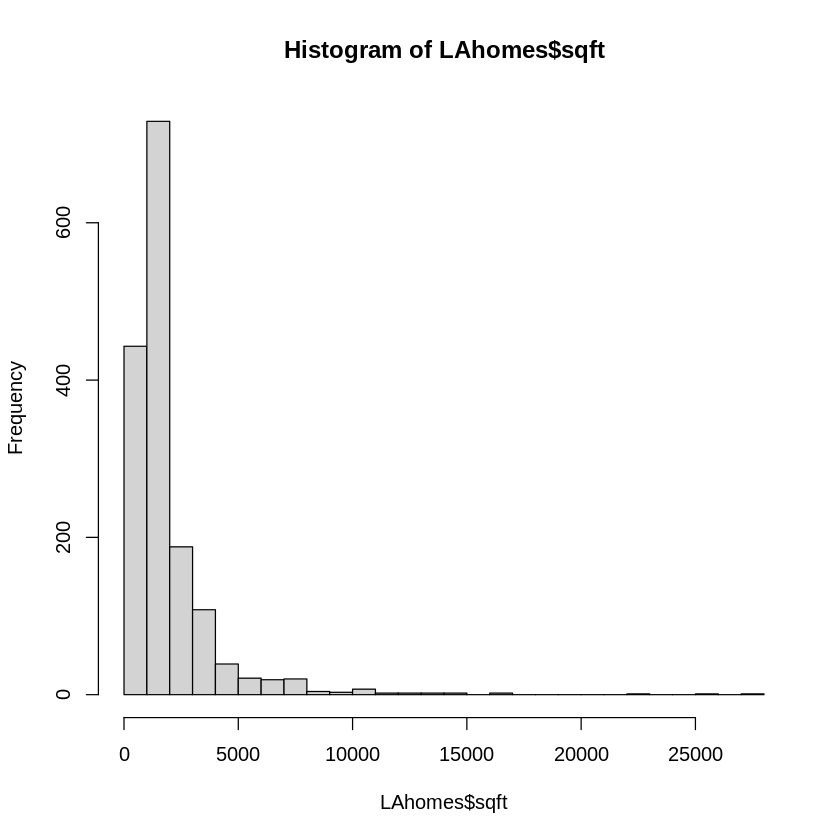

In [27]:
hist(LAhomes$sqft, breaks = 20)

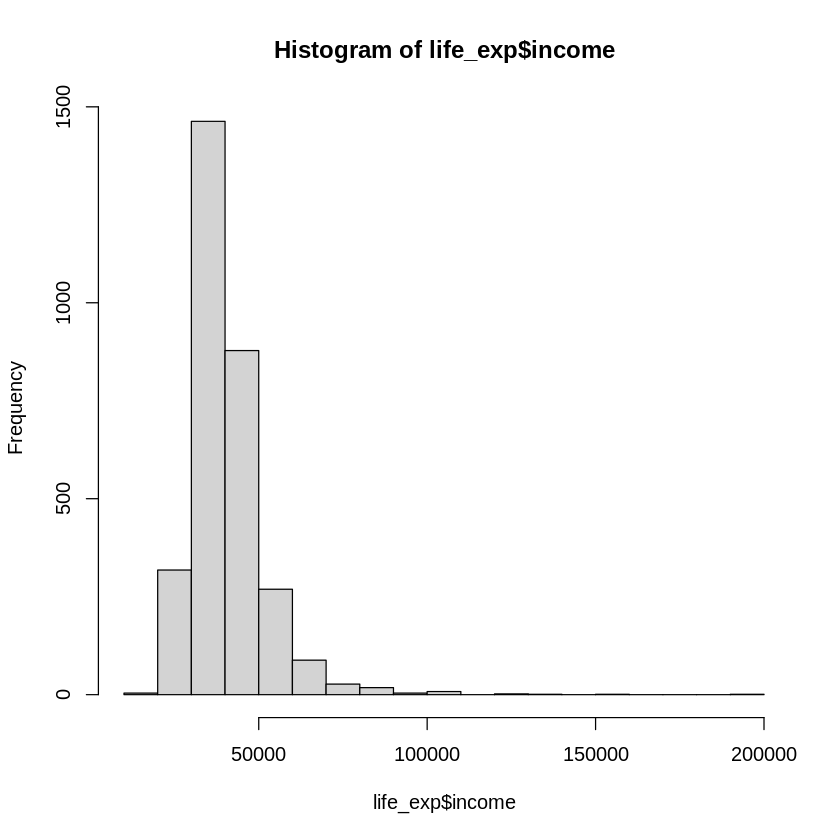

In [ ]:
hist(life_exp$income)

#### respuestas:
usar tantas celdas de código y texto como sea necesario

In [ ]:
hist(life_exp$income), breaks= 5

ERROR: Error in parse(text = input): <text>:1:22: unexpected ','
1: hist(life_exp$income),
                         ^


observación: estás colocando el parametro `breaks` fuera del paréntesis. lo correcto era

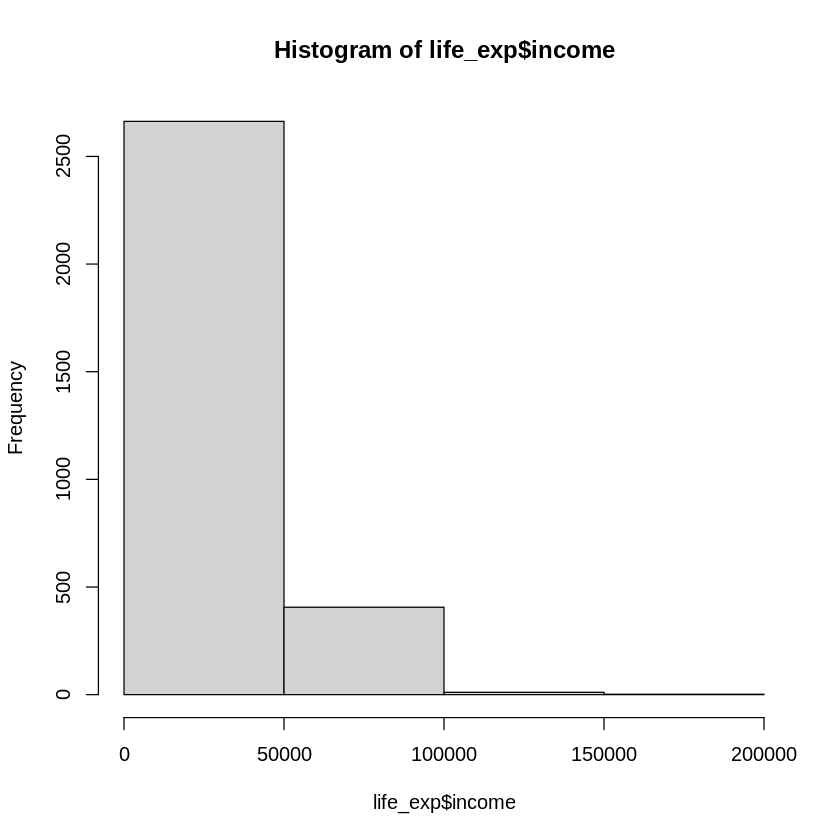

In [28]:
hist(life_exp$income, breaks= 5)

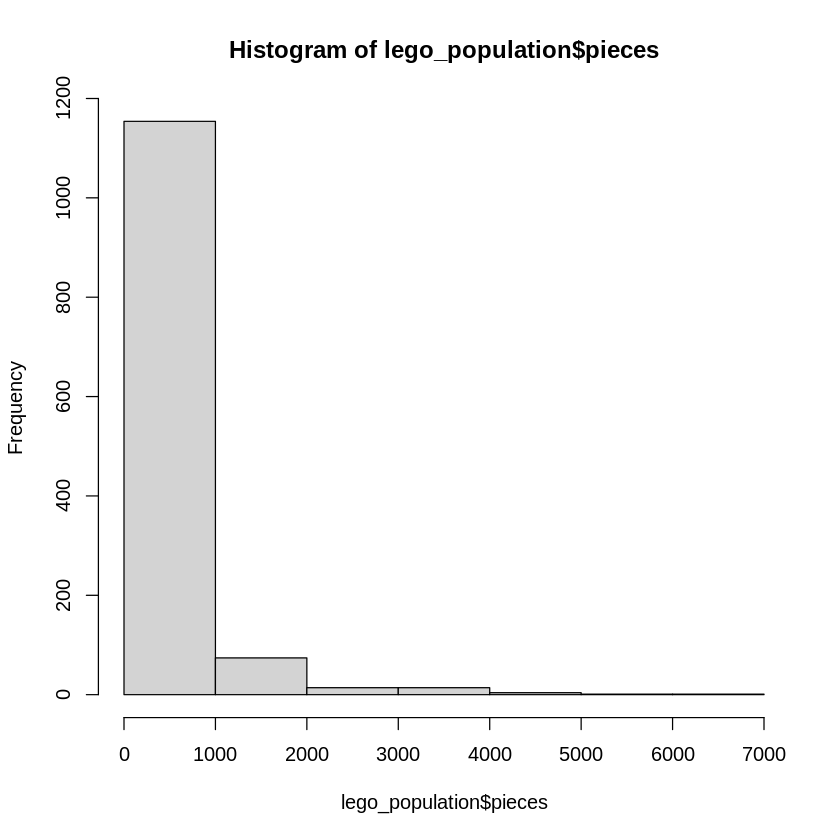

In [29]:
hist(lego_population$pieces, breaks=5)

#### respuestas:
usar tantas celdas de código y texto como sea necesario

observación: no indicaste nada en este ejercicio